In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

data_path = "/content/drive/MyDrive/Weather-Dataset"
os.listdir(data_path)

['StormEvents_details-ftp_v1.0_d1996_c20250520.csv',
 'StormEvents_details-ftp_v1.0_d1997_c20250520.csv',
 'StormEvents_details-ftp_v1.0_d1998_c20250520.csv',
 'StormEvents_details-ftp_v1.0_d1999_c20250520.csv',
 'StormEvents_details-ftp_v1.0_d2000_c20250520.csv',
 'StormEvents_details-ftp_v1.0_d2001_c20250520.csv',
 'StormEvents_details-ftp_v1.0_d2002_c20250520.csv',
 'StormEvents_details-ftp_v1.0_d2003_c20250520.csv',
 'StormEvents_details-ftp_v1.0_d2004_c20250520.csv',
 'StormEvents_details-ftp_v1.0_d2005_c20250520.csv',
 'StormEvents_details-ftp_v1.0_d2006_c20250520.csv',
 'StormEvents_details-ftp_v1.0_d2007_c20250520.csv',
 'StormEvents_details-ftp_v1.0_d2008_c20251204.csv',
 'StormEvents_details-ftp_v1.0_d2009_c20250520.csv',
 'StormEvents_details-ftp_v1.0_d2010_c20250520.csv',
 'StormEvents_details-ftp_v1.0_d2011_c20250520.csv',
 'StormEvents_details-ftp_v1.0_d2012_c20250520.csv',
 'StormEvents_details-ftp_v1.0_d2013_c20250520.csv',
 'StormEvents_details-ftp_v1.0_d2014_c20250520

In [4]:
import pandas as pd
import glob

files = glob.glob(data_path + "/*.csv")

df_list = []

for file in files:
    df_list.append(pd.read_csv(file))

storm_df = pd.concat(df_list, ignore_index=True)

print(storm_df.shape)

/tmp/ipykernel_7661/2941235635.py:9: DtypeWarning: Columns (26,28) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list.append(pd.read_csv(file))
/tmp/ipykernel_7661/2941235635.py:9: DtypeWarning: Columns (28) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list.append(pd.read_csv(file))
/tmp/ipykernel_7661/2941235635.py:9: DtypeWarning: Columns (28) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list.append(pd.read_csv(file))
/tmp/ipykernel_7661/2941235635.py:9: DtypeWarning: Columns (29,34,35,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list.append(pd.read_csv(file))


(1776001, 51)


In [5]:
storm_df["STATE"] = storm_df["STATE"].astype(str).str.strip().str.upper()

In [6]:
target_states = [
    "WASHINGTON",
    "TEXAS",
    "TENNESSEE",
    "MAINE",
    "NEW HAMPSHIRE",
    "VERMONT",
    "MASSACHUSETTS",
    "RHODE ISLAND",
    "CONNECTICUT"
]

In [7]:
selected_weather = storm_df[storm_df["STATE"].isin(target_states)]

print(selected_weather.shape)
selected_weather.head()

(239056, 51)


,BEGIN_YEARMONTH,BEGIN_DAY,BEGIN_TIME,END_YEARMONTH,END_DAY,END_TIME,EPISODE_ID,EVENT_ID,STATE,STATE_FIPS,...,END_RANGE,END_AZIMUTH,END_LOCATION,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,EPISODE_NARRATIVE,EVENT_NARRATIVE,DATA_SOURCE
5,199601,17,2250,199601,17,2250,2404529.0,5535851,TEXAS,48.0,...,NaN,NaN,WACO,31.55,-97.15,31.55,-97.15,"The ""Best for Less"" hotel office roof was blow...",NaN,PDC
6,199601,18,845,199601,18,850,1000285.0,5535517,TENNESSEE,47.0,...,NaN,NaN,GEORGETOWN,36.02,-88.97,36.02,-88.97,Two homes were damaged and 18 golf cart houses...,NaN,PDC
15,199601,2,2100,199601,3,900,1009772.0,5551545,MASSACHUSETTS,25.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A strong low pressure system moved from Tennes...,NaN,PDC
17,199601,2,2100,199601,3,900,2036763.0,5551978,RHODE ISLAND,44.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A strong low pressure system moved from Tennes...,NaN,PDC
21,199601,7,1700,199601,8,1700,2036764.0,5551979,RHODE ISLAND,44.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,An intense east coast low pressure system move...,NaN,PDC


In [8]:
selected_weather["STATE"].value_counts()

,count
STATE,
TEXAS,130981
TENNESSEE,41270
MASSACHUSETTS,15292
MAINE,14849
VERMONT,10048
WASHINGTON,9783
NEW HAMPSHIRE,7949
CONNECTICUT,6500
RHODE ISLAND,2384


In [9]:
storm_types = selected_weather.groupby(["STATE","EVENT_TYPE"]).size()

storm_types.sort_values(ascending=False).head(20)

STATE          EVENT_TYPE       
TEXAS          Hail                 39767
               Thunderstorm Wind    25953
               Drought              17863
TENNESSEE      Thunderstorm Wind    17228
TEXAS          Flash Flood          13530
TENNESSEE      Hail                  6224
TEXAS          High Wind             5766
               Heat                  4671
               Tornado               4142
MASSACHUSETTS  Thunderstorm Wind     3901
TENNESSEE      Flash Flood           3279
WASHINGTON     Heavy Snow            3188
TEXAS          Winter Weather        3076
MAINE          Heavy Snow            2934
               Thunderstorm Wind     2586
VERMONT        Winter Weather        2277
MASSACHUSETTS  Strong Wind           2121
TEXAS          Winter Storm          2093
CONNECTICUT    Thunderstorm Wind     2073
VERMONT        Winter Storm          2070
dtype: int64

In [10]:
tornadoes = selected_weather[selected_weather["EVENT_TYPE"] == "Tornado"]

tornadoes["STATE"].value_counts()

,count
STATE,
TEXAS,4142
TENNESSEE,1118
WASHINGTON,81
MASSACHUSETTS,68
CONNECTICUT,65
MAINE,58
NEW HAMPSHIRE,37
VERMONT,18
RHODE ISLAND,12


In [11]:
#HAZARD PROFILES
hazard_profile = selected_weather.groupby(["STATE","EVENT_TYPE"]).agg(
    total_events=("EVENT_TYPE","count"),
    avg_magnitude=("MAGNITUDE","mean"),
    max_magnitude=("MAGNITUDE","max")
)

hazard_profile

total_events  avg_magnitude  max_magnitude
STATE       EVENT_TYPE                                                       
CONNECTICUT Astronomical Low Tide             1            NaN            NaN
            Blizzard                         47            NaN            NaN
            Coastal Flood                    67            NaN            NaN
            Cold/Wind Chill                  57            NaN            NaN
            Drought                          73            NaN            NaN
...                                         ...            ...            ...
WASHINGTON  Volcanic Ash                      1            NaN            NaN
            Waterspout                        2            NaN            NaN
            Wildfire                        539            NaN            NaN
            Winter Storm                    282            NaN            NaN
            Winter Weather                  409            NaN            NaN

[285 rows x 3 columns]

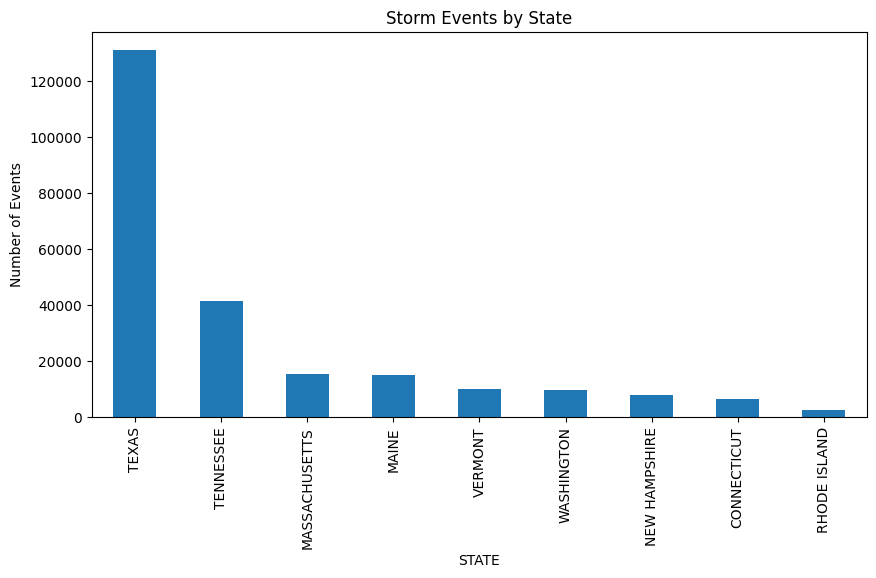

In [12]:
import matplotlib.pyplot as plt

selected_weather["STATE"].value_counts().plot(kind="bar", figsize=(10,5))
plt.title("Storm Events by State")
plt.ylabel("Number of Events")
plt.show()

In [13]:
tx_weather = storm_df[storm_df["STATE"] == "TEXAS"]
tn_weather = storm_df[storm_df["STATE"] == "TENNESSEE"]
wa_weather = storm_df[storm_df["STATE"] == "WASHINGTON"]
ne_weather = storm_df[storm_df["STATE"].isin([
    "MAINE","NEW HAMPSHIRE","VERMONT",
    "MASSACHUSETTS","RHODE ISLAND","CONNECTICUT"
])]

In [14]:
#HAZARD SCORE
storm_df["STATE"] = storm_df["STATE"].str.strip().str.upper()

storm_df["MAGNITUDE"] = pd.to_numeric(storm_df["MAGNITUDE"], errors="coerce")

storm_df["DAMAGE_PROPERTY"] = pd.to_numeric(
    storm_df["DAMAGE_PROPERTY"]
    .replace(r"[KMB]", "", regex=True),
    errors="coerce"
)

In [15]:
target_states = [
    "WASHINGTON",
    "TEXAS",
    "TENNESSEE",
    "MAINE",
    "NEW HAMPSHIRE",
    "VERMONT",
    "MASSACHUSETTS",
    "RHODE ISLAND",
    "CONNECTICUT"
]

region_df = storm_df[storm_df["STATE"].isin(target_states)]

In [16]:
hazard_metrics = region_df.groupby("STATE").agg(
    frequency=("EVENT_TYPE", "count"),
    avg_magnitude=("MAGNITUDE", "mean"),
    max_magnitude=("MAGNITUDE", "max"),
    damage=("DAMAGE_PROPERTY", "sum")
)

hazard_metrics

,frequency,avg_magnitude,max_magnitude,damage
STATE,,,,
CONNECTICUT,6500,42.202232,96.0,52134.59
MAINE,14849,41.239201,96.0,98733.65
MASSACHUSETTS,15292,41.424738,90.0,124201.88
NEW HAMPSHIRE,7949,37.065117,134.0,76393.86
RHODE ISLAND,2384,42.629773,75.0,13364.73
TENNESSEE,41270,39.011770,113.0,368273.03
TEXAS,130981,24.125092,120.0,1176713.92
VERMONT,10048,38.789126,143.0,167494.46
WASHINGTON,9783,45.326730,95.0,205370.21


In [17]:
hazard_norm = (hazard_metrics - hazard_metrics.min()) / (
    hazard_metrics.max() - hazard_metrics.min()
)

In [18]:
hazard_norm["hazard_score"] = (
    0.4 * hazard_norm["frequency"]
    + 0.2 * hazard_norm["avg_magnitude"]
    + 0.2 * hazard_norm["max_magnitude"]
    + 0.2 * hazard_norm["damage"]
)

hazard_norm.sort_values("hazard_score", ascending=False)

,frequency,avg_magnitude,max_magnitude,damage,hazard_score
STATE,,,,,
TEXAS,1.000000,0.000000,0.661765,1.000000,0.732353
TENNESSEE,0.302387,0.702148,0.558824,0.305075,0.434164
VERMONT,0.059597,0.691646,1.000000,0.132488,0.388666
NEW HAMPSHIRE,0.043275,0.610331,0.867647,0.054179,0.323741
WASHINGTON,0.057536,1.000000,0.294118,0.165045,0.314847
MAINE,0.096931,0.807207,0.308824,0.073382,0.276655
MASSACHUSETTS,0.100376,0.815958,0.220588,0.095274,0.266514
CONNECTICUT,0.032007,0.852629,0.308824,0.033326,0.251759
RHODE ISLAND,0.000000,0.872795,0.000000,0.000000,0.174559


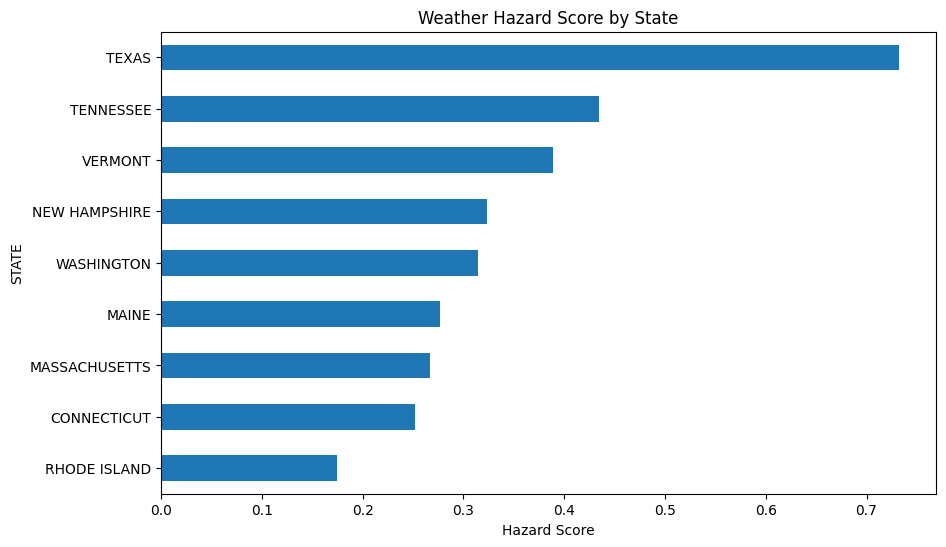

In [19]:
import matplotlib.pyplot as plt

hazard_norm["hazard_score"].sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Weather Hazard Score by State")
plt.xlabel("Hazard Score")
plt.show()

In [20]:
storm_counts = (
    region_df
    .groupby(["STATE","EVENT_TYPE"])
    .size()
    .reset_index(name="EVENT_COUNT")
)

In [21]:
main_risk = storm_counts.loc[
    storm_counts.groupby("STATE")["EVENT_COUNT"].idxmax()
]

In [22]:
main_risk.sort_values("EVENT_COUNT", ascending=False)

,STATE,EVENT_TYPE,EVENT_COUNT
198,TEXAS,Hail,39767
174,TENNESSEE,Thunderstorm Wind,17228
85,MASSACHUSETTS,Thunderstorm Wind,3901
268,WASHINGTON,Heavy Snow,3188
46,MAINE,Heavy Snow,2934
246,VERMONT,Winter Weather,2277
21,CONNECTICUT,Thunderstorm Wind,2073
119,NEW HAMPSHIRE,Thunderstorm Wind,1971
144,RHODE ISLAND,Strong Wind,430


In [23]:
!pip install plotly --quiet

In [24]:
import pandas as pd
import plotly.express as px

In [25]:
storm_df["STATE"] = storm_df["STATE"].astype(str).str.strip().str.upper()
storm_df["EVENT_TYPE"] = storm_df["EVENT_TYPE"].astype(str).str.strip()

In [26]:
target_states = [
    "WASHINGTON",
    "TEXAS",
    "TENNESSEE",
    "MAINE",
    "NEW HAMPSHIRE",
    "VERMONT",
    "MASSACHUSETTS",
    "RHODE ISLAND",
    "CONNECTICUT"
]

region_df = storm_df[storm_df["STATE"].isin(target_states)].copy()
print(region_df.shape)
region_df.head()

(239056, 51)


,BEGIN_YEARMONTH,BEGIN_DAY,BEGIN_TIME,END_YEARMONTH,END_DAY,END_TIME,EPISODE_ID,EVENT_ID,STATE,STATE_FIPS,...,END_RANGE,END_AZIMUTH,END_LOCATION,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,EPISODE_NARRATIVE,EVENT_NARRATIVE,DATA_SOURCE
5,199601,17,2250,199601,17,2250,2404529.0,5535851,TEXAS,48.0,...,NaN,NaN,WACO,31.55,-97.15,31.55,-97.15,"The ""Best for Less"" hotel office roof was blow...",NaN,PDC
6,199601,18,845,199601,18,850,1000285.0,5535517,TENNESSEE,47.0,...,NaN,NaN,GEORGETOWN,36.02,-88.97,36.02,-88.97,Two homes were damaged and 18 golf cart houses...,NaN,PDC
15,199601,2,2100,199601,3,900,1009772.0,5551545,MASSACHUSETTS,25.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A strong low pressure system moved from Tennes...,NaN,PDC
17,199601,2,2100,199601,3,900,2036763.0,5551978,RHODE ISLAND,44.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A strong low pressure system moved from Tennes...,NaN,PDC
21,199601,7,1700,199601,8,1700,2036764.0,5551979,RHODE ISLAND,44.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,An intense east coast low pressure system move...,NaN,PDC


In [27]:
storm_counts = (
    region_df
    .groupby(["STATE", "EVENT_TYPE"])
    .size()
    .reset_index(name="EVENT_COUNT")
)

storm_counts.head()

,STATE,EVENT_TYPE,EVENT_COUNT
0,CONNECTICUT,Astronomical Low Tide,1
1,CONNECTICUT,Blizzard,47
2,CONNECTICUT,Coastal Flood,67
3,CONNECTICUT,Cold/Wind Chill,57
4,CONNECTICUT,Drought,73


In [28]:
main_risk = storm_counts.loc[
    storm_counts.groupby("STATE")["EVENT_COUNT"].idxmax()
].copy()

main_risk = main_risk.rename(columns={"EVENT_TYPE": "MAIN_RISK"})
main_risk = main_risk.sort_values("STATE")

main_risk

,STATE,MAIN_RISK,EVENT_COUNT
21,CONNECTICUT,Thunderstorm Wind,2073
46,MAINE,Heavy Snow,2934
85,MASSACHUSETTS,Thunderstorm Wind,3901
119,NEW HAMPSHIRE,Thunderstorm Wind,1971
144,RHODE ISLAND,Strong Wind,430
174,TENNESSEE,Thunderstorm Wind,17228
198,TEXAS,Hail,39767
246,VERMONT,Winter Weather,2277
268,WASHINGTON,Heavy Snow,3188


In [29]:
state_abbrev = {
    "WASHINGTON": "WA",
    "TEXAS": "TX",
    "TENNESSEE": "TN",
    "MAINE": "ME",
    "NEW HAMPSHIRE": "NH",
    "VERMONT": "VT",
    "MASSACHUSETTS": "MA",
    "RHODE ISLAND": "RI",
    "CONNECTICUT": "CT"
}

main_risk["STATE_ABBR"] = main_risk["STATE"].map(state_abbrev)
main_risk

,STATE,MAIN_RISK,EVENT_COUNT,STATE_ABBR
21,CONNECTICUT,Thunderstorm Wind,2073,CT
46,MAINE,Heavy Snow,2934,ME
85,MASSACHUSETTS,Thunderstorm Wind,3901,MA
119,NEW HAMPSHIRE,Thunderstorm Wind,1971,NH
144,RHODE ISLAND,Strong Wind,430,RI
174,TENNESSEE,Thunderstorm Wind,17228,TN
198,TEXAS,Hail,39767,TX
246,VERMONT,Winter Weather,2277,VT
268,WASHINGTON,Heavy Snow,3188,WA


In [30]:
fig = px.choropleth(
    main_risk,
    locations="STATE_ABBR",
    locationmode="USA-states",
    color="MAIN_RISK",
    scope="usa",
    hover_name="STATE",
    hover_data={
        "STATE_ABBR": False,
        "EVENT_COUNT": True,
        "MAIN_RISK": True
    },
    title="Primary Weather Hazard by State"
)

fig.update_layout(
    width=1000,
    height=600
)

fig.show()

---
#START HERE
#Project

---

#Add time and season columns

In [31]:
import pandas as pd

storm_df["BEGIN_DATE_TIME"] = pd.to_datetime(storm_df["BEGIN_DATE_TIME"], errors="coerce")

storm_df["YEAR"] = storm_df["BEGIN_DATE_TIME"].dt.year
storm_df["MONTH"] = storm_df["BEGIN_DATE_TIME"].dt.month

/tmp/ipykernel_7661/63914476.py:3: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



---

#Define Seasons

In [32]:
def get_season(month):
    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5]:
        return "Spring"
    elif month in [6,7,8]:
        return "Summer"
    else:
        return "Fall"

storm_df["SEASON"] = storm_df["MONTH"].apply(get_season)

---

#Filter to Regions

In [33]:
region_df = storm_df[storm_df["STATE"].isin(target_states)].copy()

---

#Count events per Season

In [34]:
event_counts = (
    region_df
    .groupby(["STATE","SEASON","EVENT_TYPE"])
    .size()
    .reset_index(name="EVENT_COUNT")
)

---

#Compute total weeks per season

In [35]:
num_years = region_df["YEAR"].nunique()
weeks_per_season = 13 * num_years

---

#Weekly probability per event

In [36]:
event_counts["WEEKLY_PROB"] = event_counts["EVENT_COUNT"] / weeks_per_season

---

#Compute severity

In [37]:
region_df["MAGNITUDE"] = pd.to_numeric(region_df["MAGNITUDE"], errors="coerce")

---

#Average severity

In [38]:
severity = (
    region_df
    .groupby(["STATE","SEASON","EVENT_TYPE"])["MAGNITUDE"]
    .mean()
    .reset_index(name="AVG_SEVERITY")
)

---

#Merge probability and severity

In [39]:
hazard_model = pd.merge(
    event_counts,
    severity,
    on=["STATE","SEASON","EVENT_TYPE"],
    how="left"
)

---

#Model probability of power issues

Now we create a scales risk function.

Basic idea:

- Higher severity = higher chance of outage
- Some events inherently more dangerous

---

Assign base risk by event type

In [40]:
base_risk = {
    "Tornado": 0.9,
    "Thunderstorm Wind": 0.7,
    "Ice Storm": 0.95,
    "Winter Storm": 0.6,
    "Hail": 0.4,
    "Flood": 0.5,
    "Flash Flood": 0.6,
    "Heavy Rain": 0.3
}

---

Normalize severity

In [41]:
hazard_model["AVG_SEVERITY"] = hazard_model["AVG_SEVERITY"].fillna(0)

hazard_model["SEVERITY_NORM"] = (
    (hazard_model["AVG_SEVERITY"] - hazard_model["AVG_SEVERITY"].min()) /
    (hazard_model["AVG_SEVERITY"].max() - hazard_model["AVG_SEVERITY"].min())
)

---

Compute power outage probability

In [42]:
hazard_model["BASE_RISK"] = hazard_model["EVENT_TYPE"].map(base_risk).fillna(0.3)

hazard_model["POWER_OUTAGE_PROB"] = (
    hazard_model["BASE_RISK"] *
    (0.5 + 0.5 * hazard_model["SEVERITY_NORM"])
)

---

Final output table

In [43]:
hazard_model = hazard_model[[
    "STATE",
    "SEASON",
    "EVENT_TYPE",
    "WEEKLY_PROB",
    "AVG_SEVERITY",
    "POWER_OUTAGE_PROB"
]]

hazard_model.sort_values(["STATE","SEASON","WEEKLY_PROB"], ascending=False).head(20)

,STATE,SEASON,EVENT_TYPE,WEEKLY_PROB,AVG_SEVERITY,POWER_OUTAGE_PROB
794,WASHINGTON,Winter,Heavy Snow,6.164103,0.000000,0.150000
796,WASHINGTON,Winter,High Wind,2.233333,53.559482,0.209955
809,WASHINGTON,Winter,Winter Weather,0.823077,0.000000,0.150000
788,WASHINGTON,Winter,Flood,0.651282,0.000000,0.250000
808,WASHINGTON,Winter,Winter Storm,0.607692,0.000000,0.300000
797,WASHINGTON,Winter,Ice Storm,0.310256,0.000000,0.475000
802,WASHINGTON,Winter,Strong Wind,0.241026,41.053191,0.195955
793,WASHINGTON,Winter,Heavy Rain,0.192308,0.000000,0.150000
782,WASHINGTON,Winter,Debris Flow,0.161538,0.000000,0.150000
781,WASHINGTON,Winter,Cold/Wind Chill,0.117949,0.000000,0.150000


In [44]:
!pip install ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 18.2 MB/s eta 0:00:00


In [45]:
import ipywidgets as widgets
from IPython.display import display

states = sorted(hazard_model["STATE"].unique())

state_dropdown = widgets.Dropdown(
    options=states,
    description="State:",
    value=states[0]
)

display(state_dropdown)

Dropdown(description='State:', options=('CONNECTICUT', 'MAINE', 'MASSACHUSETTS', 'NEW HAMPSHIRE', 'RHODE ISLAN…

In [46]:
def show_state_data(state):
    filtered = hazard_model[hazard_model["STATE"] == state]
    display(filtered.sort_values("WEEKLY_PROB", ascending=False))

In [47]:
widgets.interactive(show_state_data, state=state_dropdown)

interactive(children=(Dropdown(description='State:', options=('CONNECTICUT', 'MAINE', 'MASSACHUSETTS', 'NEW HA…